<h2>GCD & Euclid's algorithm</h2>
We will first review some grade school number theory and an ancient algorithm attributed to Euclid in his book Elements.
First, we review the concept of the greatest common divisor (GCD) of two numbers.

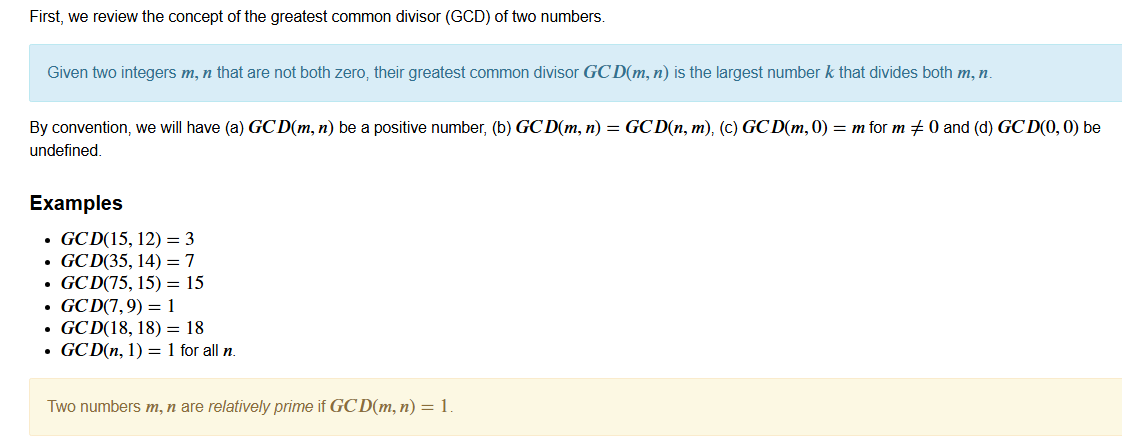

<h3>GCD Using Euclid's algorithm</h3>

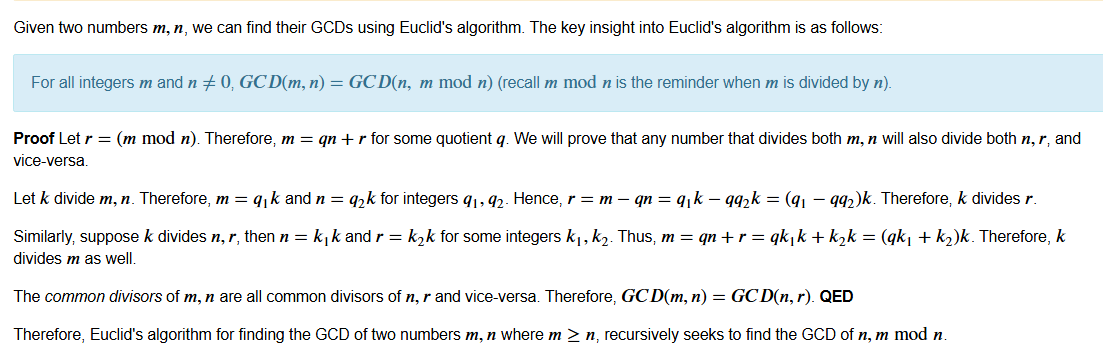



In [1]:
def euclids_algorithm(m, n):
    if m < 0: 
        m = -m  # make them positive
    if n < 0: 
        n = -n 
    if m < n:
        (m, n) = (n, m) # make n as smaller number of two (m,n are abritrary and can be interchanged)
    assert m >= n and m >= 1 and n >= 0
    if n == 0:
        return m if m != 0 else None 
    
    print(f'GCD({m}, {n})')
    
    while n > 0:
        (m, n) = (n, m % n) # the new value of m = n, and new value n = m % n
        print(f'= GCD({m}, {n})')

    assert n == 0
    print(f'= {m}')
    return m

In [2]:
euclids_algorithm(15, 12)

GCD(15, 12)
= GCD(12, 3)
= GCD(3, 0)
= 3


3

In [3]:
euclids_algorithm(10909014081, 1092091)

GCD(10909014081, 1092091)
= GCD(1092091, 117082)
= GCD(117082, 38353)
= GCD(38353, 2023)
= GCD(2023, 1939)
= GCD(1939, 84)
= GCD(84, 7)
= GCD(7, 0)
= 7


7

<h2> Running time of Euclid's algorithm </h2>

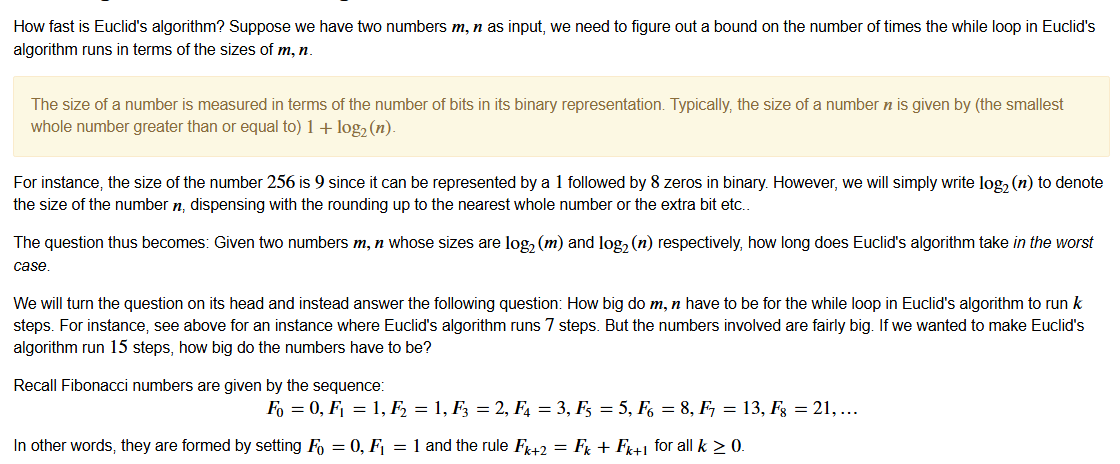


Assume  we are running Euclids algorithm on 2 numbers m,n m>=n, m>0 and n>=0

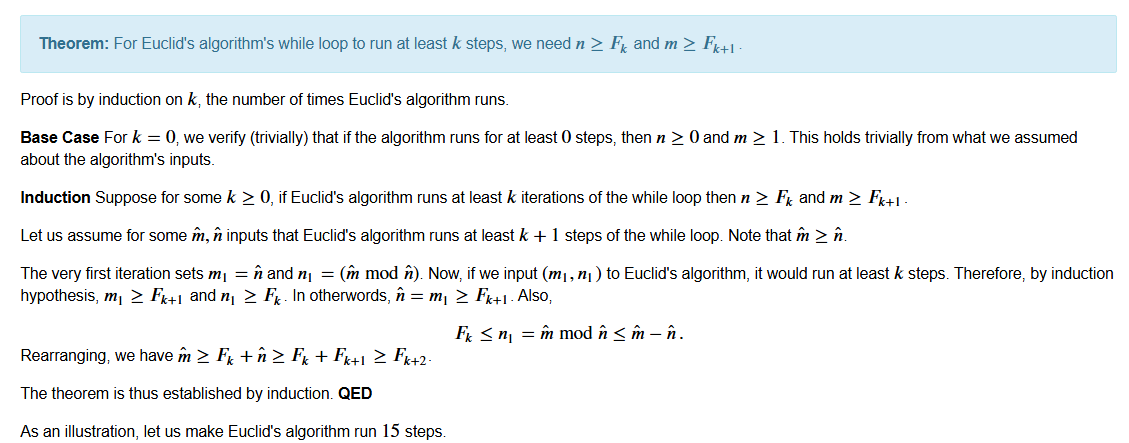

Notice how Fibonacci numbers occur in each of the GCD steps

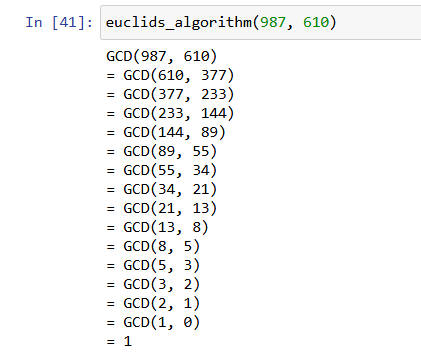

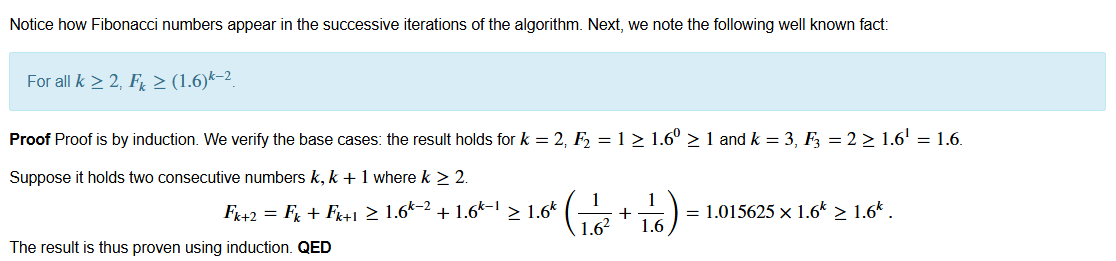

combining all above proof we finally can prove runtime of Euclids algorithm is is O(l), where l = number of bits of m (note - m is chosen as the bigger number of the 2 numbers whose GCD is being calculated)

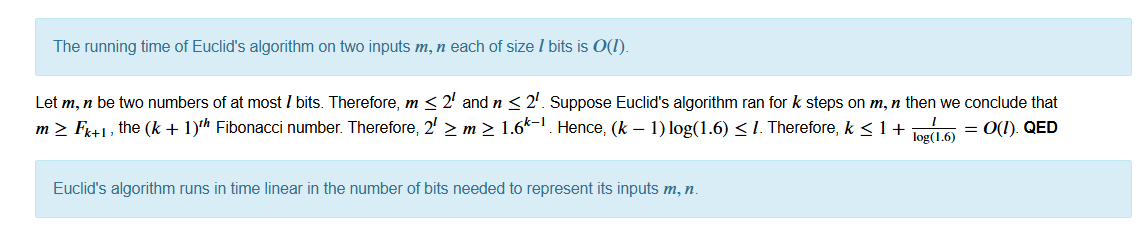


<h2>Bezout's theorem and extended Euclid's Algorithm</h2>

Next, we will go over a simple extension to Euclid's algorithm that will be quite helpful in developing the RSA cryptosystem. This is a theorem by the famous French mathematician Etienne Bezout.

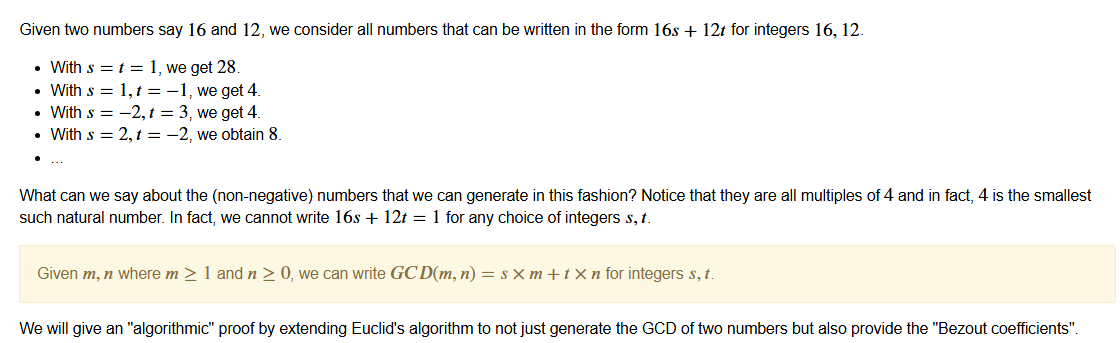



In [4]:
def extended_euclid(m, n):
    assert m >= 1 and n >= 0 and m >= n
    m0, n0 = m, n # let's remember the initial values
    (s, t) = (1, 0)# m = s * m0 + t * n0 # just multiplying with 1 and 0 initially
    (s_hat, t_hat) = (0, 1) # n = s_hat * m0 + t_hat * n0 # just multiplying with 0 and 1 initially
    while n > 0:
        assert m == s * m0 + t * n0
        assert n == s_hat * m0 + t_hat * n0
        q = m // n # compute the integer quotient 
        r = m % n # the reminder 
        # m = q * n + r, or alternatively, r = m - q * n = (s-q*s_hat) * m_0 + (t - q * t_hat)* n_0   # TODO - follow up how this is derived
        a, b = (s - q*s_hat, t - q * t_hat)
        (m, n, s, t, s_hat, t_hat) = (n, r, s_hat, t_hat, a, b)
        print(f'GCD({m0}, {n0}) = GCD({m}, {n})')
        print(f'\t {m} = {s}*{m0} + {t} * {n0}')
        print(f'\t {n} = {s_hat}*{m0} + {t_hat} * {n0}')
    return m, s, t
        

In [5]:
(g,s,t) = extended_euclid(20,7) # n=33 = 11x3. Totient(33)=20. e=7 is relatively prime to 20. extended_GCD(totient(n),e) = extended_euclid(20,7) which gives d= coefficient of e = (3) ..see the last GCD step where 1 is GCD
# after all this design/running code we can publish public and private keys  (e,n), (d,n) respectively


GCD(20, 7) = GCD(7, 6)
	 7 = 0*20 + 1 * 7
	 6 = 1*20 + -2 * 7
GCD(20, 7) = GCD(6, 1)
	 6 = 1*20 + -2 * 7
	 1 = -1*20 + 3 * 7
GCD(20, 7) = GCD(1, 0)
	 1 = -1*20 + 3 * 7
	 0 = 7*20 + -20 * 7


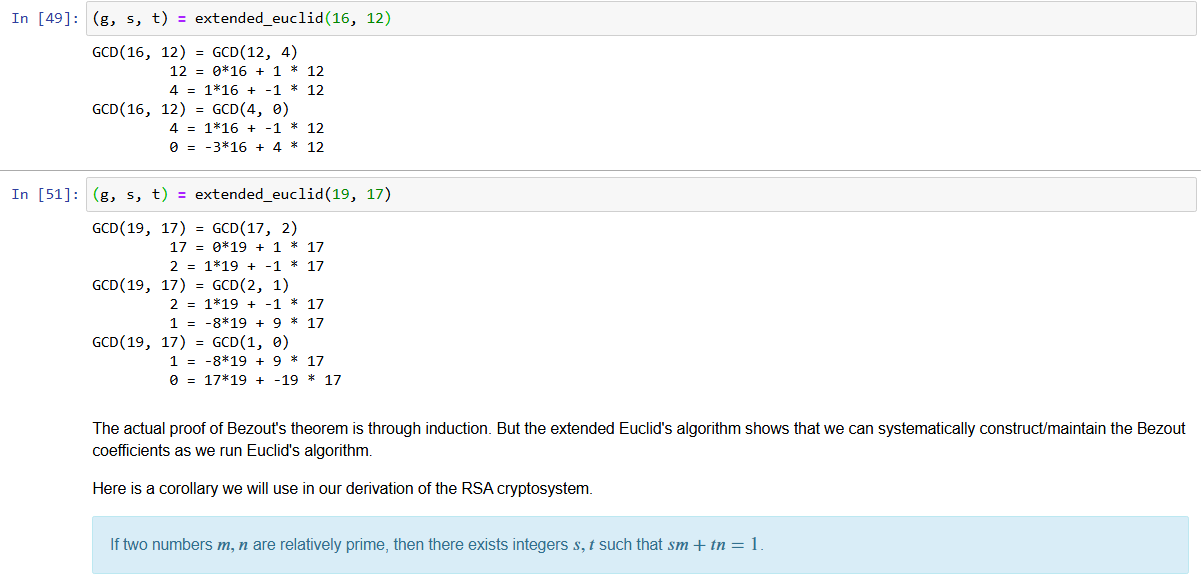

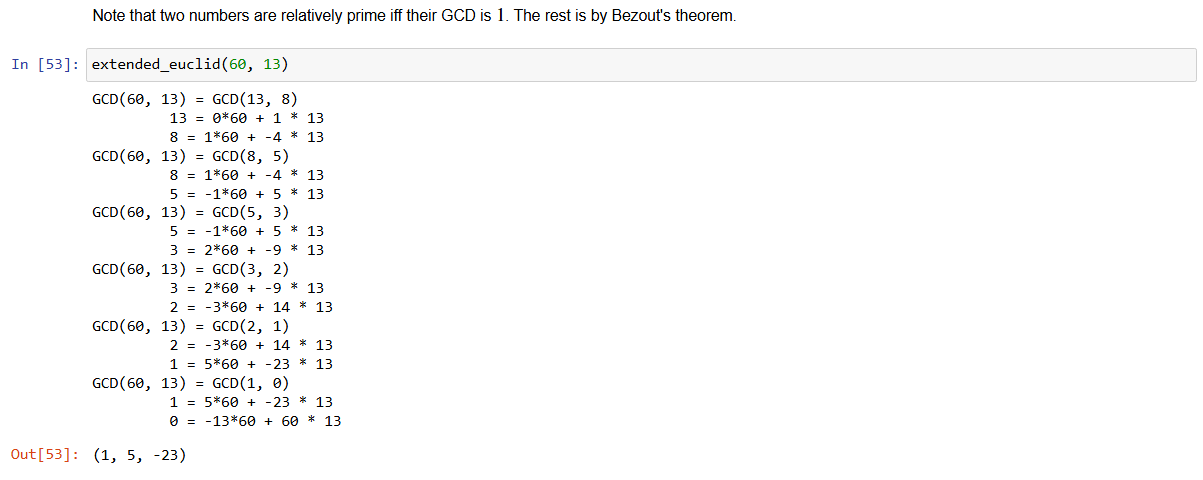

Hopefully, the small primer on number theory brings back some memories from high-school and undergraduate mathematics. If not, welcome to the party!! Please get comfortable with the concepts in these notes and review the proofs, especially proof by induction. Next, we will derive the RSA scheme for public key cryptography.